In [1]:
# Task1: Calculate the Cost of Supply from Manufacturing to Distribution

import pandas as pd

dist = pd.read_excel("distribution.xlsx", sheet_name="Distribution")

dist["Route Cost (USD)"] = dist["Unit Distribution"] * dist["Transfer cost per unit"]

total_cost = dist["Route Cost (USD)"].sum()
print(f"Total Cost of Supply (Manufacturing -> Distribution) = ${total_cost:,.2f}\n")

table = dist[[
    "Site Code PRD",
    "Site Code GDC",
    "Unit Distribution",
    "Transfer cost per unit",
    "Route Cost (USD)"
]].copy()

table["Site Code PRD"] = table["Site Code PRD"].astype(str)
table["Site Code GDC"] = table["Site Code GDC"].astype(str)
table = table.sort_values(["Site Code PRD", "Site Code GDC"]).reset_index(drop=True)

pd.set_option("display.float_format", "{:,.6f}".format)
display(table)

Total Cost of Supply (Manufacturing -> Distribution) = $58,714,245.92



,Site Code PRD,Site Code GDC,Unit Distribution,Transfer cost per unit,Route Cost (USD)
0,KRCH,ARBU,0,0.624905,0.000000
1,KRCH,CNBE,3408728,0.052977,"180,583.869967"
2,KRCH,ESMA,0,0.705577,0.000000
3,KRCH,INMU,4065649,0.698433,"2,839,584.048892"
4,KRCH,JPTO,11502802,0.970282,"11,160,967.336879"
5,KRCH,PLWA,4298980,0.773487,"3,325,206.074833"
6,KRCH,USNE,1364802,0.619161,"845,031.751630"
7,KRCH,USSA,0,0.886828,0.000000
8,PLLU,ARBU,0,0.449957,0.000000
9,PLLU,CNBE,4131069,0.558353,"2,306,593.038102"


In [2]:
# Task2: Calculate the Optimal Cost from Manufacturing to Distribution if the cost is 0.1 USD per Unit per 1000 km

import pulp

prod = pd.read_excel("production.xlsx")
dist = pd.read_excel("distribution.xlsx", sheet_name="Distribution")
conn = pd.read_excel("connections.xlsx")

supply = prod.set_index("Site Code")["Unit Production"].astype(float).to_dict()
prd_list = sorted(supply.keys(), key=str)

demand = dist.groupby("Site Code GDC")["Unit Distribution"].sum().astype(float).to_dict()
gdc_list = sorted(demand.keys(), key=str)

pmp_gdc = conn[conn["Type"] == "PMP-GDC"].copy()
pmp_gdc[["PRD", "GDC"]] = pmp_gdc["Connection"].astype(str).str.split("-", expand=True)
pmp_gdc["PRD"] = pmp_gdc["PRD"].str.strip()
pmp_gdc["GDC"] = pmp_gdc["GDC"].str.strip()
pmp_gdc["Distance"] = pmp_gdc["Distance"].astype(float)

pmp_gdc = pmp_gdc.groupby(["PRD", "GDC"], as_index=False)["Distance"].min()

pmp_gdc = pmp_gdc[pmp_gdc["PRD"].isin(prd_list) & pmp_gdc["GDC"].isin(gdc_list)].copy()

arcs = list(zip(pmp_gdc["PRD"], pmp_gdc["GDC"]))
dist_km = {(r["PRD"], r["GDC"]): float(r["Distance"]) for _, r in pmp_gdc.iterrows()}
cost = {a: 0.1 * (dist_km[a] / 1000.0) for a in arcs} 

model = pulp.LpProblem("Task2_PRD_to_GDC_MinCost", pulp.LpMinimize)

x = pulp.LpVariable.dicts("x", arcs, lowBound=0)

model += pulp.lpSum(x[a] * cost[a] for a in arcs)

for p in prd_list:
    model += pulp.lpSum(x[(p, g)] for (pp, g) in arcs if pp == p) == supply[p]

for g in gdc_list:
    model += pulp.lpSum(x[(p, g)] for (p, gg) in arcs if gg == g) == demand[g]

model.solve(pulp.PULP_CBC_CMD(msg=False))

status = pulp.LpStatus[model.status]
print("Solution status:", status)
if status != "Optimal":
    raise RuntimeError("No optimal solution")

total_opt_cost = pulp.value(model.objective)
print(f"Optimal Cost (Manufacturing -> Distribution) = ${total_opt_cost:,.2f}\n")

rows = []
for (p, g) in arcs:
    units = x[(p, g)].value()
    if units and units > 1e-6:
        rows.append({
            "PRD": p,
            "GDC": g,
            "Distance (km)": dist_km[(p, g)],
            "Cost per unit (USD)": cost[(p, g)],
            "Units shipped": units,
            "Route Cost (USD)": units * cost[(p, g)]
        })

table = pd.DataFrame(rows).sort_values(["PRD", "GDC"]).reset_index(drop=True)

pd.set_option("display.float_format", "{:,.6f}".format)
display(table)

Solution status: Optimal
Optimal Cost (Manufacturing -> Distribution) = $51,895,575.84



,PRD,GDC,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,KRCH,CNBE,"1,158.040000",0.115804,"3,836,459.000000","444,277.298036"
1,KRCH,JPTO,"1,052.770000",0.105277,"20,804,502.000000","2,190,235.557054"
2,PLLU,CNBE,"6,919.960000",0.691996,"3,180,756.000000","2,201,070.428976"
3,PLLU,ESMA,"2,352.710000",0.235271,"12,607,065.000000","2,966,076.789615"
4,PLLU,PLWA,151.620000,0.015162,"21,510,792.000000","326,146.628304"
5,TRME,CNBE,"6,267.550000",0.626755,"6,322,882.000000","3,962,897.907910"
6,TRME,INMU,"3,945.720000",0.394572,"33,845,679.000000","13,354,557.254388"
7,USAM,ARBU,"8,804.050000",0.880405,"24,933,403.000000","21,951,492.668215"
8,USAM,JPTO,"10,008.240000",1.000824,"222,019.000000","222,201.943656"
9,USAM,USNE,"2,705.020000",0.270502,"15,440,562.000000","4,176,702.902124"


In [3]:
# Task3: Calculate the Optimal Cost of the Supply from Manufacturing to Distribution to Warehouse if the cost is 0.1 USD per Unit per 1000 km

prod = pd.read_excel("production.xlsx", sheet_name="Production")
dist = pd.read_excel("distribution.xlsx", sheet_name="Distribution")
conn = pd.read_excel("connections.xlsx")

supply = prod.set_index("Site Code")["Unit Production"].astype(float).to_dict()
prd_list = sorted(supply.keys(), key=str)

demand_gdc = dist.groupby("Site Code GDC")["Unit Distribution"].sum().astype(float).to_dict()
gdc_list = sorted(demand_gdc.keys(), key=str)

pg = conn[conn["Type"] == "PMP-GDC"].copy()
pg[["PRD", "GDC"]] = pg["Connection"].astype(str).str.split("-", expand=True)
pg["PRD"] = pg["PRD"].str.strip()
pg["GDC"] = pg["GDC"].str.strip()
pg["Distance"] = pg["Distance"].astype(float)

pg = pg[pg["PRD"].isin(prd_list) & pg["GDC"].isin(gdc_list)].copy()

pg = pg.groupby(["PRD", "GDC"], as_index=False)["Distance"].min()

pg["Cost_per_unit"] = 0.1 * (pg["Distance"] / 1000.0)

pg_arcs = list(zip(pg["PRD"], pg["GDC"]))
cost_pg = {(r.PRD, r.GDC): r.Cost_per_unit for r in pg.itertuples(index=False)}
dist_pg = {(r.PRD, r.GDC): r.Distance for r in pg.itertuples(index=False)}

gw = conn[conn["Type"] == "GDC-WHS"].copy()
gw[["GDC", "WHS"]] = gw["Connection"].astype(str).str.split("-", expand=True)
gw["GDC"] = gw["GDC"].str.strip()
gw["WHS"] = gw["WHS"].str.strip()
gw["Distance"] = gw["Distance"].astype(float)

gw = gw[gw["GDC"].isin(gdc_list)].copy()

gw = gw.groupby(["GDC", "WHS"], as_index=False)["Distance"].min()

gw["Cost_per_unit"] = 0.1 * (gw["Distance"] / 1000.0)

gw_arcs = list(zip(gw["GDC"], gw["WHS"]))
cost_gw = {(r.GDC, r.WHS): r.Cost_per_unit for r in gw.itertuples(index=False)}
dist_gw = {(r.GDC, r.WHS): r.Distance for r in gw.itertuples(index=False)}

model = pulp.LpProblem("PRD_GDC_WHS_MinCost", pulp.LpMinimize)

x = pulp.LpVariable.dicts("x_pg", pg_arcs, lowBound=0)  # PRD->GDC
y = pulp.LpVariable.dicts("y_gw", gw_arcs, lowBound=0)  # GDC->WHS

model += (
    pulp.lpSum(x[a] * cost_pg[a] for a in pg_arcs) +
    pulp.lpSum(y[a] * cost_gw[a] for a in gw_arcs)
)

for p in prd_list:
    model += pulp.lpSum(x[(pp, g)] for (pp, g) in pg_arcs if pp == p) == supply[p]

for g in gdc_list:
    model += pulp.lpSum(x[(p, gg)] for (p, gg) in pg_arcs if gg == g) == demand_gdc[g]

for g in gdc_list:
    model += pulp.lpSum(y[(gg, w)] for (gg, w) in gw_arcs if gg == g) == demand_gdc[g]

model.solve(pulp.PULP_CBC_CMD(msg=False))

status = pulp.LpStatus[model.status]
print("Solution status:", status)
if status != "Optimal":
    raise RuntimeError("No optimal solution")

total_opt_cost = pulp.value(model.objective)
print(f"Optimal Cost (PRD -> GDC -> WHS) = ${total_opt_cost:,.2f}\n")

rows_pg = []
for (p, g) in pg_arcs:
    units = x[(p, g)].value()
    if units and units > 1e-6:
        rows_pg.append({
            "PRD": p,
            "GDC": g,
            "Distance (km)": dist_pg[(p, g)],
            "Cost per unit (USD)": cost_pg[(p, g)],
            "Units shipped": units,
            "Route Cost (USD)": units * cost_pg[(p, g)]
        })

rows_gw = []
for (g, w) in gw_arcs:
    units = y[(g, w)].value()
    if units and units > 1e-6:
        rows_gw.append({
            "GDC": g,
            "WHS": w,
            "Distance (km)": dist_gw[(g, w)],
            "Cost per unit (USD)": cost_gw[(g, w)],
            "Units shipped": units,
            "Route Cost (USD)": units * cost_gw[(g, w)]
        })

tab_pg = pd.DataFrame(rows_pg).sort_values(["PRD", "GDC"]).reset_index(drop=True)
tab_gw = pd.DataFrame(rows_gw).sort_values(["GDC", "WHS"]).reset_index(drop=True)

pd.set_option("display.float_format", "{:,.6f}".format)

print("PRD -> GDC shipments:")
display(tab_pg)

print("GDC -> WHS shipments:")
display(tab_gw)

Solution status: Optimal
Optimal Cost (PRD -> GDC -> WHS) = $67,219,922.83

PRD -> GDC shipments:


,PRD,GDC,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,KRCH,CNBE,"1,158.040000",0.115804,"3,836,459.000000","444,277.298036"
1,KRCH,JPTO,"1,052.770000",0.105277,"20,804,502.000000","2,190,235.557054"
2,PLLU,CNBE,"6,919.960000",0.691996,"3,180,756.000000","2,201,070.428976"
3,PLLU,ESMA,"2,352.710000",0.235271,"12,607,065.000000","2,966,076.789615"
4,PLLU,PLWA,151.620000,0.015162,"21,510,792.000000","326,146.628304"
5,TRME,CNBE,"6,267.550000",0.626755,"6,322,882.000000","3,962,897.907910"
6,TRME,INMU,"3,945.720000",0.394572,"33,845,679.000000","13,354,557.254388"
7,USAM,ARBU,"8,804.050000",0.880405,"24,933,403.000000","21,951,492.668215"
8,USAM,JPTO,"10,008.240000",1.000824,"222,019.000000","222,201.943656"
9,USAM,USNE,"2,705.020000",0.270502,"15,440,562.000000","4,176,702.902124"


GDC -> WHS shipments:


,GDC,WHS,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,ARBU,ARWH,5.830000,0.000583,"24,933,403.000000","14,536.173949"
1,CNBE,CNWH,941.900000,0.094190,"13,340,097.000000","1,256,503.736430"
2,ESMA,PTWH,374.810000,0.037481,"12,607,065.000000","472,525.403265"
3,INMU,MMWH,"2,438.320000",0.243832,"33,845,679.000000","8,252,659.601928"
4,JPTO,CNWH,"1,757.050000",0.175705,"21,026,521.000000","3,694,464.872305"
5,PLWA,PLWH,391.700000,0.039170,"21,510,792.000000","842,577.722640"
6,USNE,USWH,406.640000,0.040664,"15,440,562.000000","627,875.013168"
7,USSA,MXWH,"3,028.030000",0.302803,"538,979.000000","163,204.458137"


In [4]:
# Task4: Create a Python Code to generate a Map with the locations similar to the one in the page before

import folium

loc = pd.read_excel("locations 1.xlsx", sheet_name="pmp")

loc["Site_code"] = loc["Site_code"].astype(str).str.strip()
loc["Type"] = loc["Type"].astype(str).str.strip()

center_lat = loc["Y_cord"].mean()
center_lon = loc["X_cord"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=2, tiles="CartoDB positron")

type_color = {
    "PMP": "blue",
    "GDC": "green",
    "WHS": "orange",
    "MKT": "red"
}

layers = {}
for t in sorted(loc["Type"].unique()):
    layers[t] = folium.FeatureGroup(name=t, show=True)
    m.add_child(layers[t])

for _, r in loc.iterrows():
    t = r["Type"]
    code = r["Site_code"]
    city = str(r.get("City", ""))
    country = str(r.get("Country", ""))

    popup_text = f"{t} | {code}<br>{city}, {country}"

    folium.CircleMarker(
        location=[float(r["Y_cord"]), float(r["X_cord"])],
        radius=6,
        color=type_color.get(t, "gray"),
        fill=True,
        fill_opacity=0.85,
        popup=folium.Popup(popup_text, max_width=250)
    ).add_to(layers[t])

m.fit_bounds([
    [loc["Y_cord"].min(), loc["X_cord"].min()],
    [loc["Y_cord"].max(), loc["X_cord"].max()]
])

folium.LayerControl(collapsed=False).add_to(m)

m

In [5]:
# Task5: Calculate the Optimal Cost of the Supply from Manufacturing to Distribution to Warehouse to Market if the cost is 0.1 USD per Unit per 1000 km

prod = pd.read_excel("production.xlsx", sheet_name="Production")
dist = pd.read_excel("distribution.xlsx", sheet_name="Distribution")
conn = pd.read_excel("connections.xlsx")

supply = prod.set_index("Site Code")["Unit Production"].astype(float).to_dict()
prd_list = sorted(supply.keys(), key=str)

demand_gdc = dist.groupby("Site Code GDC")["Unit Distribution"].sum().astype(float).to_dict()
gdc_list = sorted(demand_gdc.keys(), key=str)

def build_arcs(df, conn_type, left_name, right_name, keep_left_codes=None, keep_right_codes=None):
    sub = df[df["Type"] == conn_type].copy()
    sub[[left_name, right_name]] = sub["Connection"].astype(str).str.split("-", expand=True)
    sub[left_name] = sub[left_name].str.strip()
    sub[right_name] = sub[right_name].str.strip()
    sub["Distance"] = sub["Distance"].astype(float)

    if keep_left_codes is not None:
        sub = sub[sub[left_name].isin(keep_left_codes)]
    if keep_right_codes is not None:
        sub = sub[sub[right_name].isin(keep_right_codes)]

    sub = sub.groupby([left_name, right_name], as_index=False)["Distance"].min()
    sub["Cost_per_unit"] = 0.1 * (sub["Distance"] / 1000.0)

    arcs = list(zip(sub[left_name], sub[right_name]))
    cost = {(r[0], r[1]): r[2] for r in sub[[left_name, right_name, "Cost_per_unit"]].itertuples(index=False, name=None)}
    dist_km = {(r[0], r[1]): r[2] for r in sub[[left_name, right_name, "Distance"]].itertuples(index=False, name=None)}
    return arcs, cost, dist_km, sub

pg_arcs, cost_pg, dist_pg, pg_df = build_arcs(conn, "PMP-GDC", "PRD", "GDC",
                                              keep_left_codes=set(prd_list),
                                              keep_right_codes=set(gdc_list))

gw_arcs, cost_gw, dist_gw, gw_df = build_arcs(conn, "GDC-WHS", "GDC", "WHS",
                                              keep_left_codes=set(gdc_list))

whs_list = sorted(gw_df["WHS"].unique().tolist(), key=str)

wm_arcs, cost_wm, dist_wm, wm_df = build_arcs(conn, "WHS-MKT", "WHS", "MKT",
                                              keep_left_codes=set(whs_list))

mkt_list = sorted(wm_df["MKT"].unique().tolist(), key=str)

total_supply = sum(supply.values())


model = pulp.LpProblem("PRD_GDC_WHS_MKT_MinCost", pulp.LpMinimize)

x_pg = pulp.LpVariable.dicts("x_pg", pg_arcs, lowBound=0)  # PRD->GDC
x_gw = pulp.LpVariable.dicts("x_gw", gw_arcs, lowBound=0)  # GDC->WHS
x_wm = pulp.LpVariable.dicts("x_wm", wm_arcs, lowBound=0)  # WHS->MKT

model += (
    pulp.lpSum(x_pg[a] * cost_pg[a] for a in pg_arcs) +
    pulp.lpSum(x_gw[a] * cost_gw[a] for a in gw_arcs) +
    pulp.lpSum(x_wm[a] * cost_wm[a] for a in wm_arcs)
)

for p in prd_list:
    model += pulp.lpSum(x_pg[(pp, g)] for (pp, g) in pg_arcs if pp == p) == supply[p]

for g in gdc_list:
    model += pulp.lpSum(x_pg[(p, gg)] for (p, gg) in pg_arcs if gg == g) == demand_gdc[g]

for g in gdc_list:
    inflow = pulp.lpSum(x_pg[(p, gg)] for (p, gg) in pg_arcs if gg == g)
    outflow = pulp.lpSum(x_gw[(gg, w)] for (gg, w) in gw_arcs if gg == g)
    model += inflow == outflow

for w in whs_list:
    inflow = pulp.lpSum(x_gw[(g, ww)] for (g, ww) in gw_arcs if ww == w)
    outflow = pulp.lpSum(x_wm[(ww, m)] for (ww, m) in wm_arcs if ww == w)
    model += inflow == outflow

model += pulp.lpSum(x_wm[(w, m)] for (w, m) in wm_arcs) == total_supply

model.solve(pulp.PULP_CBC_CMD(msg=False))

status = pulp.LpStatus[model.status]
print("Solution status:", status)
if status != "Optimal":
    raise RuntimeError("No optimal solution")

total_opt_cost = pulp.value(model.objective)
print(f"Optimal Cost (PRD -> GDC -> WHS -> MKT) = ${total_opt_cost:,.2f}\n")

def make_table(var_dict, arcs, left, right, dist_dict, cost_dict, sort_cols):
    rows = []
    for a in arcs:
        v = var_dict[a].value()
        if v and v > 1e-6:
            rows.append({
                left: a[0],
                right: a[1],
                "Distance (km)": dist_dict[a],
                "Cost per unit (USD)": cost_dict[a],
                "Units shipped": v,
                "Route Cost (USD)": v * cost_dict[a]
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(sort_cols).reset_index(drop=True)

tab_pg = make_table(x_pg, pg_arcs, "PRD", "GDC", dist_pg, cost_pg, ["PRD", "GDC"])
tab_gw = make_table(x_gw, gw_arcs, "GDC", "WHS", dist_gw, cost_gw, ["GDC", "WHS"])
tab_wm = make_table(x_wm, wm_arcs, "WHS", "MKT", dist_wm, cost_wm, ["WHS", "MKT"])

pd.set_option("display.float_format", "{:,.6f}".format)

print("PRD -> GDC shipments:")
display(tab_pg)

print("GDC -> WHS shipments:")
display(tab_gw)

print("WHS -> MKT shipments:")
display(tab_wm)

Solution status: Optimal
Optimal Cost (PRD -> GDC -> WHS -> MKT) = $74,741,347.39

PRD -> GDC shipments:


,PRD,GDC,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,KRCH,CNBE,"1,158.040000",0.115804,"3,836,459.000000","444,277.298036"
1,KRCH,JPTO,"1,052.770000",0.105277,"20,804,502.000000","2,190,235.557054"
2,PLLU,CNBE,"6,919.960000",0.691996,"3,180,756.000000","2,201,070.428976"
3,PLLU,ESMA,"2,352.710000",0.235271,"12,607,065.000000","2,966,076.789615"
4,PLLU,PLWA,151.620000,0.015162,"21,510,792.000000","326,146.628304"
5,TRME,CNBE,"6,267.550000",0.626755,"6,322,882.000000","3,962,897.907910"
6,TRME,INMU,"3,945.720000",0.394572,"33,845,679.000000","13,354,557.254388"
7,USAM,ARBU,"8,804.050000",0.880405,"24,933,403.000000","21,951,492.668215"
8,USAM,JPTO,"10,008.240000",1.000824,"222,019.000000","222,201.943656"
9,USAM,USNE,"2,705.020000",0.270502,"15,440,562.000000","4,176,702.902124"


GDC -> WHS shipments:


,GDC,WHS,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,ARBU,ARWH,5.830000,0.000583,"24,933,403.000000","14,536.173949"
1,CNBE,CNWH,941.900000,0.094190,"13,340,097.000000","1,256,503.736430"
2,ESMA,PTWH,374.810000,0.037481,"12,607,065.000000","472,525.403265"
3,INMU,MMWH,"2,438.320000",0.243832,"33,845,679.000000","8,252,659.601928"
4,JPTO,CNWH,"1,757.050000",0.175705,"21,026,521.000000","3,694,464.872305"
5,PLWA,PLWH,391.700000,0.039170,"21,510,792.000000","842,577.722640"
6,USNE,USWH,406.640000,0.040664,"15,440,562.000000","627,875.013168"
7,USSA,MXWH,"3,028.030000",0.302803,"538,979.000000","163,204.458137"


WHS -> MKT shipments:


,WHS,MKT,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,ARWH,AR,522.930000,0.052293,"24,933,403.000000","1,303,842.443079"
1,CNWH,CN,230.010000,0.023001,"34,366,618.000000","790,466.580618"
2,MMWH,TH,567.200000,0.056720,"33,845,679.000000","1,919,726.912880"
3,MXWH,MX,575.890000,0.057589,"538,979.000000","31,039.261631"
4,PLWH,PL,295.910000,0.029591,"21,510,792.000000","636,525.846072"
5,PTWH,PT,196.300000,0.019630,"12,607,065.000000","247,476.685950"
6,USWH,US,"1,678.920000",0.167892,"15,440,562.000000","2,592,346.835304"


In [6]:
# Task6: Calculate the Optimal Cost of the Supply from Manufacturing to Distribution to Warehouse to Market if the cost is 0.1 USD per Unit per 1000 km, 
# and you need to cover the Market Demands

# Assumption: all production must be shipped (ship == supply)
# Requirement: cover market demands (shipments to each market >= demand)

prod = pd.read_excel("production.xlsx")
conn = pd.read_excel("connections.xlsx")
dem = pd.read_excel("demand.xlsx")
loc = pd.read_excel("locations 1.xlsx", sheet_name="pmp")

loc["Site_code"] = loc["Site_code"].astype(str).str.strip()
loc["City"] = loc["City"].astype(str).str.strip()
loc["Country"] = loc["Country"].astype(str).str.strip()
city_of = loc.set_index("Site_code")["City"].to_dict()
country_of = loc.set_index("Site_code")["Country"].to_dict()

supply = prod.set_index("Site Code")["Unit Production"].astype(float).to_dict()
prd_list = sorted(supply.keys(), key=str)

dem["Country_Code"] = dem["Country_Code"].astype(str).str.strip()
demand_mkt = dem.set_index("Country_Code")["Unit Demand"].astype(float).to_dict()
mkt_list = sorted(demand_mkt.keys(), key=str)

def build_arcs(conn_type, left, right):
    sub = conn[conn["Type"] == conn_type].copy()
    sub[[left, right]] = sub["Connection"].astype(str).str.split("-", expand=True)
    sub[left] = sub[left].str.strip()
    sub[right] = sub[right].str.strip()
    sub["Distance"] = sub["Distance"].astype(float)

    sub = sub.groupby([left, right], as_index=False)["Distance"].min()

    sub["Cost_per_unit"] = 0.1 * (sub["Distance"] / 1000.0)
    arcs = list(zip(sub[left], sub[right]))
    cost = {(r[left], r[right]): float(r["Cost_per_unit"]) for _, r in sub.iterrows()}
    dist_km = {(r[left], r[right]): float(r["Distance"]) for _, r in sub.iterrows()}
    return arcs, cost, dist_km, sub

pg_arcs, cost_pg, dist_pg, pg_df = build_arcs("PMP-GDC", "PRD", "GDC")
gw_arcs, cost_gw, dist_gw, gw_df = build_arcs("GDC-WHS", "GDC", "WHS")
wm_arcs, cost_wm, dist_wm, wm_df = build_arcs("WHS-MKT", "WHS", "MKT")

pg_arcs = [(p,g) for (p,g) in pg_arcs if p in prd_list]
wm_arcs = [(w,m) for (w,m) in wm_arcs if m in mkt_list]

gdc_list = sorted({g for (_, g) in pg_arcs}, key=str)
whs_list = sorted({w for (_, w) in gw_arcs} | {w for (w, _) in wm_arcs}, key=str)

model = pulp.LpProblem("Task6_PRD_GDC_WHS_MKT_MinCost", pulp.LpMinimize)

x_pg = pulp.LpVariable.dicts("x_pg", pg_arcs, lowBound=0)  # PRD -> GDC
x_gw = pulp.LpVariable.dicts("x_gw", gw_arcs, lowBound=0)  # GDC -> WHS
x_wm = pulp.LpVariable.dicts("x_wm", wm_arcs, lowBound=0)  # WHS -> MKT

model += (
    pulp.lpSum(x_pg[a] * cost_pg[a] for a in pg_arcs) +
    pulp.lpSum(x_gw[a] * cost_gw[a] for a in gw_arcs) +
    pulp.lpSum(x_wm[a] * cost_wm[a] for a in wm_arcs)
)

for p in prd_list:
    model += pulp.lpSum(x_pg[(pp, g)] for (pp, g) in pg_arcs if pp == p) == supply[p]

for g in gdc_list:
    inflow = pulp.lpSum(x_pg[(p, gg)] for (p, gg) in pg_arcs if gg == g)
    outflow = pulp.lpSum(x_gw[(gg, w)] for (gg, w) in gw_arcs if gg == g)
    model += inflow == outflow

for w in whs_list:
    inflow = pulp.lpSum(x_gw[(g, ww)] for (g, ww) in gw_arcs if ww == w)
    outflow = pulp.lpSum(x_wm[(ww, m)] for (ww, m) in wm_arcs if ww == w)
    model += inflow == outflow

for m in mkt_list:
    model += pulp.lpSum(x_wm[(w, mm)] for (w, mm) in wm_arcs if mm == m) >= demand_mkt[m]

model.solve(pulp.PULP_CBC_CMD(msg=False))

status = pulp.LpStatus[model.status]
print("Solution status:", status)
if status != "Optimal":
    raise RuntimeError("No optimal solution")

total_opt_cost = pulp.value(model.objective)
print(f"Optimal Cost (PRD -> GDC -> WHS -> MKT) with Market Demands = ${total_opt_cost:,.2f}\n")

def make_table(var_dict, arcs, left, right, dist_dict, cost_dict, sort_cols):
    rows = []
    for a in arcs:
        v = var_dict[a].value()
        if v and v > 1e-6:
            rows.append({
                left: a[0],
                right: a[1],
                "Distance (km)": dist_dict[a],
                "Cost per unit (USD)": cost_dict[a],
                "Units shipped": v,
                "Route Cost (USD)": v * cost_dict[a]
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(sort_cols).reset_index(drop=True)

tab_pg = make_table(x_pg, pg_arcs, "PRD", "GDC", dist_pg, cost_pg, ["PRD","GDC"])
tab_gw = make_table(x_gw, gw_arcs, "GDC", "WHS", dist_gw, cost_gw, ["GDC","WHS"])
tab_wm = make_table(x_wm, wm_arcs, "WHS", "MKT", dist_wm, cost_wm, ["WHS","MKT"])

pd.set_option("display.float_format", "{:,.6f}".format)

print("PRD -> GDC shipments:")
display(tab_pg)

print("GDC -> WHS shipments:")
display(tab_gw)

print("WHS -> MKT shipments (meets market demands):")
display(tab_wm)

Solution status: Optimal
Optimal Cost (PRD -> GDC -> WHS -> MKT) with Market Demands = $69,479,231.47

PRD -> GDC shipments:


,PRD,GDC,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,KRCH,CNBE,"1,158.040000",0.115804,"21,319,782.000000","2,468,916.034728"
1,KRCH,JPTO,"1,052.770000",0.105277,"3,321,178.700000","349,643.730000"
2,PLLU,PLWA,151.620000,0.015162,"37,298,613.000000","565,521.570306"
3,TRME,PLWA,"1,920.560000",0.192056,"40,168,561.000000","7,714,613.151416"
4,USAM,ARBU,"8,804.050000",0.880405,"2,806,304.200000","2,470,684.249201"
5,USAM,USNE,"2,705.020000",0.270502,"32,400,243.000000","8,764,330.531986"
6,USAM,USSA,"1,853.810000",0.185381,"5,928,415.600000","1,099,015.612344"


GDC -> WHS shipments:


,GDC,WHS,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,ARBU,ARWH,5.830000,0.000583,"2,806,304.200000","1,636.075349"
1,CNBE,CNWH,941.900000,0.094190,"12,502,410.000000","1,177,601.997900"
2,CNBE,VNWH,"2,200.170000",0.220017,"8,817,371.900000","1,939,971.713322"
3,JPTO,TLWH,"5,172.800000",0.517280,"3,321,178.700000","1,717,979.317936"
4,PLWA,BAWH,892.080000,0.089208,"3,767,280.300000","336,071.541002"
5,PLWA,CZWH,628.460000,0.062846,"8,643,055.700000","543,181.478522"
6,PLWA,DEWH,915.970000,0.091597,"4,894,915.000000","448,359.529255"
7,PLWA,EGWH,"2,452.740000",0.245274,"5,163,408.900000","1,266,449.954539"
8,PLWA,KWWH,"3,396.030000",0.339603,"4,729,780.200000","1,606,247.545261"
9,PLWA,NLWH,"1,061.540000",0.106154,"4,993,604.500000","530,091.092093"


WHS -> MKT shipments (meets market demands):


,WHS,MKT,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,ARWH,AR,522.930000,0.052293,"954,557.230000","49,916.661228"
1,ARWH,CL,"1,204.200000",0.120420,"1,851,747.000000","222,987.373740"
2,BAWH,IT,533.880000,0.053388,"1,998,559.700000","106,699.105264"
3,BAWH,NG,"4,023.190000",0.402319,"1,768,720.600000","711,589.903071"
4,CNWH,CN,230.010000,0.023001,"1,441,701.000000","33,160.564701"
5,CNWH,ID,"3,622.490000",0.362249,"623,014.090000","225,686.231088"
6,CNWH,IN,"3,208.870000",0.320887,"336,991.470000","108,136.181834"
7,CNWH,JP,"1,644.030000",0.164403,"845,727.470000","139,040.133250"
8,CNWH,KR,783.000000,0.078300,"4,713,562.600000","369,071.951580"
9,CNWH,PH,"2,019.350000",0.201935,"4,541,413.800000","917,070.395703"


In [7]:
# Task7: Calculate the Optimal Cost of the Supply from Manufacturing to Distribution to Warehouse to Market if the cost is 0.1 USD per Unit per 1000 km, 
# and you need to cover the Market Demands, and you cannot Shipped between the Source and Destinations Specified in File Shipment Constraints

# Same as Task 6, but we forbid the routes listed in constraints.xlsx
# (we remove those arcs and solve the same LP on the reduced network)

prod = pd.read_excel("production.xlsx")
conn = pd.read_excel("connections.xlsx")
dem = pd.read_excel("demand.xlsx")
cons = pd.read_excel("constraints.xlsx")

supply = prod.set_index("Site Code")["Unit Production"].astype(float).to_dict()
prd_list = sorted(supply.keys(), key=str)

dem["Country_Code"] = dem["Country_Code"].astype(str).str.strip()
demand_mkt = dem.set_index("Country_Code")["Unit Demand"].astype(float).to_dict()
mkt_list = sorted(demand_mkt.keys(), key=str)

cons["Constraint Type"] = cons["Constraint Type"].astype(str).str.strip()
cons["Source"] = cons["Source"].astype(str).str.strip()
cons["Destination"] = cons["Destination"].astype(str).str.strip()
forbidden = set((t, s, d) for t, s, d in zip(cons["Constraint Type"], cons["Source"], cons["Destination"]))

def build_arcs(conn_type, left, right):
    sub = conn[conn["Type"] == conn_type].copy()
    sub[[left, right]] = sub["Connection"].astype(str).str.split("-", expand=True)
    sub[left] = sub[left].str.strip()
    sub[right] = sub[right].str.strip()
    sub["Distance"] = sub["Distance"].astype(float)

    sub = sub.groupby([left, right], as_index=False)["Distance"].min()
    sub["Cost_per_unit"] = 0.1 * (sub["Distance"] / 1000.0)

    arcs = list(zip(sub[left], sub[right]))
    cost = {(r[left], r[right]): float(r["Cost_per_unit"]) for _, r in sub.iterrows()}
    dist = {(r[left], r[right]): float(r["Distance"]) for _, r in sub.iterrows()}
    return arcs, cost, dist

pg_arcs, cost_pg, dist_pg = build_arcs("PMP-GDC", "PRD", "GDC")
gw_arcs, cost_gw, dist_gw = build_arcs("GDC-WHS", "GDC", "WHS")
wm_arcs, cost_wm, dist_wm = build_arcs("WHS-MKT", "WHS", "MKT")

pg_arcs = [(p, g) for (p, g) in pg_arcs if p in prd_list]
wm_arcs = [(w, m) for (w, m) in wm_arcs if m in mkt_list]

pg_arcs = [(p, g) for (p, g) in pg_arcs if ("PMP-GDC", p, g) not in forbidden]
gw_arcs = [(g, w) for (g, w) in gw_arcs if ("GDC-WHS", g, w) not in forbidden]
wm_arcs = [(w, m) for (w, m) in wm_arcs if ("WHS-MKT", w, m) not in forbidden]

gdc_list = sorted({g for (_, g) in pg_arcs}, key=str)
whs_list = sorted({w for (_, w) in gw_arcs} | {w for (w, _) in wm_arcs}, key=str)


model = pulp.LpProblem("Task7_MinCost", pulp.LpMinimize)

x_pg = pulp.LpVariable.dicts("x_pg", pg_arcs, lowBound=0)
x_gw = pulp.LpVariable.dicts("x_gw", gw_arcs, lowBound=0)
x_wm = pulp.LpVariable.dicts("x_wm", wm_arcs, lowBound=0)

model += (
    pulp.lpSum(x_pg[a] * cost_pg[a] for a in pg_arcs) +
    pulp.lpSum(x_gw[a] * cost_gw[a] for a in gw_arcs) +
    pulp.lpSum(x_wm[a] * cost_wm[a] for a in wm_arcs)
)

for p in prd_list:
    model += pulp.lpSum(x_pg[(pp, g)] for (pp, g) in pg_arcs if pp == p) == supply[p]

for g in gdc_list:
    inflow  = pulp.lpSum(x_pg[(p, gg)] for (p, gg) in pg_arcs if gg == g)
    outflow = pulp.lpSum(x_gw[(gg, w)] for (gg, w) in gw_arcs if gg == g)
    model += inflow == outflow

for w in whs_list:
    inflow  = pulp.lpSum(x_gw[(g, ww)] for (g, ww) in gw_arcs if ww == w)
    outflow = pulp.lpSum(x_wm[(ww, m)] for (ww, m) in wm_arcs if ww == w)
    model += inflow == outflow

for m in mkt_list:
    model += pulp.lpSum(x_wm[(w, mm)] for (w, mm) in wm_arcs if mm == m) >= demand_mkt[m]

model.solve(pulp.PULP_CBC_CMD(msg=False))

status = pulp.LpStatus[model.status]
print("Solution status:", status)
if status != "Optimal":
    raise RuntimeError("No optimal solution")

total_cost = pulp.value(model.objective)
print(f"\nOPTIMAL Cost (with shipment constraints) = ${total_cost:,.2f}\n")

def make_table(var_dict, arcs, left, right, dist_dict, cost_dict, sort_cols):
    rows = []
    for a in arcs:
        v = var_dict[a].value()
        if v and v > 1e-6:
            rows.append({
                left: a[0],
                right: a[1],
                "Distance (km)": dist_dict[a],
                "Cost per unit (USD)": cost_dict[a],
                "Units shipped": v,
                "Route Cost (USD)": v * cost_dict[a]
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(sort_cols).reset_index(drop=True)

tab_pg = make_table(x_pg, pg_arcs, "PRD", "GDC", dist_pg, cost_pg, ["PRD", "GDC"])
tab_gw = make_table(x_gw, gw_arcs, "GDC", "WHS", dist_gw, cost_gw, ["GDC", "WHS"])
tab_wm = make_table(x_wm, wm_arcs, "WHS", "MKT", dist_wm, cost_wm, ["WHS", "MKT"])

pd.set_option("display.float_format", "{:,.6f}".format)

print("PRD -> GDC shipments:")
display(tab_pg)

print("GDC -> WHS shipments:")
display(tab_gw)

print("WHS -> MKT shipments:")
display(tab_wm)

Solution status: Optimal

OPTIMAL Cost (with shipment constraints) = $69,530,764.54

PRD -> GDC shipments:


,PRD,GDC,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,KRCH,CNBE,"1,158.040000",0.115804,"21,319,782.000000","2,468,916.034728"
1,KRCH,JPTO,"1,052.770000",0.105277,"3,321,178.700000","349,643.730000"
2,PLLU,PLWA,151.620000,0.015162,"37,298,613.000000","565,521.570306"
3,TRME,PLWA,"1,920.560000",0.192056,"40,168,561.000000","7,714,613.151416"
4,USAM,ARBU,"8,804.050000",0.880405,"2,806,304.200000","2,470,684.249201"
5,USAM,USNE,"2,705.020000",0.270502,"32,400,243.000000","8,764,330.531986"
6,USAM,USSA,"1,853.810000",0.185381,"5,928,415.600000","1,099,015.612344"


GDC -> WHS shipments:


,GDC,WHS,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,ARBU,ARWH,5.830000,0.000583,"2,806,304.200000","1,636.075349"
1,CNBE,CNWH,941.900000,0.094190,"12,502,410.000000","1,177,601.997900"
2,CNBE,VNWH,"2,200.170000",0.220017,"8,817,371.900000","1,939,971.713322"
3,JPTO,TLWH,"5,172.800000",0.517280,"3,321,178.700000","1,717,979.317936"
4,PLWA,BAWH,892.080000,0.089208,"3,767,280.300000","336,071.541002"
5,PLWA,CZWH,628.460000,0.062846,"8,643,055.700000","543,181.478522"
6,PLWA,DEWH,915.970000,0.091597,"4,894,915.000000","448,359.529255"
7,PLWA,GRWH,"1,588.480000",0.158848,"5,163,408.900000","820,197.176947"
8,PLWA,NLWH,"1,061.540000",0.106154,"4,993,604.500000","530,091.092093"
9,PLWA,PLWH,391.700000,0.039170,"11,763,761.000000","460,786.518370"


WHS -> MKT shipments:


,WHS,MKT,Distance (km),Cost per unit (USD),Units shipped,Route Cost (USD)
0,ARWH,AR,522.930000,0.052293,"954,557.230000","49,916.661228"
1,ARWH,CL,"1,204.200000",0.120420,"1,851,747.000000","222,987.373740"
2,BAWH,IT,533.880000,0.053388,"1,998,559.700000","106,699.105264"
3,BAWH,NG,"4,023.190000",0.402319,"1,768,720.600000","711,589.903071"
4,CNWH,CN,230.010000,0.023001,"1,441,701.000000","33,160.564701"
5,CNWH,ID,"3,622.490000",0.362249,"623,014.090000","225,686.231088"
6,CNWH,IN,"3,208.870000",0.320887,"336,991.470000","108,136.181834"
7,CNWH,JP,"1,644.030000",0.164403,"845,727.470000","139,040.133250"
8,CNWH,KR,783.000000,0.078300,"4,713,562.600000","369,071.951580"
9,CNWH,PH,"2,019.350000",0.201935,"4,541,413.800000","917,070.395703"


In [8]:
# Task8: Without taking into account the Constraints calculate the Maximum Revenue, and the minimum Supply Costs, just taking into account that all production 
# units arrives to Market, check if the Supply is the same

# 1) Check total supply vs total demand
# 2) Max revenue: cannot sell above demand, so extra supply is unsold
# 3) Min supply cost: deliver ALL production to markets via cheapest routes


prod = pd.read_excel("production.xlsx")                 
dem = pd.read_excel("demand.xlsx")                     
prices = pd.read_excel("prices.xlsx")                     
conn = pd.read_excel("connections.xlsx")                

total_supply = float(prod["Unit Production"].sum())
total_demand = float(dem["Unit Demand"].sum())

print(f"Total Supply (production) = {total_supply:,.6f}")
print(f"Total Demand  (markets)   = {total_demand:,.6f}")
print("Supply == Demand  ", "YES" if abs(total_supply - total_demand) < 1e-6 else "NO")
print()

dem2 = dem.copy()
prices2 = prices.copy()

dem2["Country_Code"] = dem2["Country_Code"].astype(str).str.strip()
prices2["Country_Code"] = prices2["Country_Code"].astype(str).str.strip()

rev_df = dem2.merge(prices2, on="Country_Code", how="left")
rev_df["Unit Demand"] = rev_df["Unit Demand"].astype(float)
rev_df["Price per Unit in USD"] = rev_df["Price per Unit in USD"].astype(float)

if total_supply >= total_demand:
    max_revenue = float((rev_df["Unit Demand"] * rev_df["Price per Unit in USD"]).sum())
    extra = total_supply - total_demand
    print(f"MAX Revenue (cover all demand) = ${max_revenue:,.2f}")
    print(f"Extra supply (cannot be sold if demand is the limit) = {extra:,.6f}\n")
else:
    mkt_list = rev_df["Country_Code"].tolist()
    demand_mkt = rev_df.set_index("Country_Code")["Unit Demand"].to_dict()
    price_mkt  = rev_df.set_index("Country_Code")["Price per Unit in USD"].to_dict()

    model_rev = pulp.LpProblem("Task8_MaxRevenue", pulp.LpMaximize)
    q = pulp.LpVariable.dicts("q", mkt_list, lowBound=0)

    model_rev += pulp.lpSum(q[m] * price_mkt[m] for m in mkt_list)
    model_rev += pulp.lpSum(q[m] for m in mkt_list) == total_supply
    for m in mkt_list:
        model_rev += q[m] <= demand_mkt[m]

    model_rev.solve(pulp.PULP_CBC_CMD(msg=False))
    max_revenue = pulp.value(model_rev.objective)
    print(f"MAX Revenue (limited supply) = ${max_revenue:,.2f}\n")

def build_arcs(conn_type, left, right):
    sub = conn[conn["Type"] == conn_type].copy()
    sub[[left, right]] = sub["Connection"].astype(str).str.split("-", expand=True)
    sub[left] = sub[left].str.strip()
    sub[right] = sub[right].str.strip()
    sub["Distance"] = sub["Distance"].astype(float)

    sub = sub.groupby([left, right], as_index=False)["Distance"].min()
    sub["Cost_per_unit"] = 0.1 * (sub["Distance"] / 1000.0)

    arcs = list(zip(sub[left], sub[right]))
    cost = {(r[left], r[right]): float(r["Cost_per_unit"]) for _, r in sub.iterrows()}
    dist = {(r[left], r[right]): float(r["Distance"]) for _, r in sub.iterrows()}
    return arcs, cost, dist

supply = prod.set_index("Site Code")["Unit Production"].astype(float).to_dict()
prd_list = sorted(supply.keys(), key=str)

pg_arcs, cost_pg, dist_pg = build_arcs("PMP-GDC", "PRD", "GDC")
gw_arcs, cost_gw, dist_gw = build_arcs("GDC-WHS", "GDC", "WHS")
wm_arcs, cost_wm, dist_wm = build_arcs("WHS-MKT", "WHS", "MKT")

pg_arcs = [(p, g) for (p, g) in pg_arcs if p in prd_list]
gdc_list = sorted({g for (_, g) in pg_arcs}, key=str)

gw_arcs = [(g, w) for (g, w) in gw_arcs if g in gdc_list]
whs_list = sorted({w for (_, w) in gw_arcs}, key=str)

wm_arcs = [(w, m) for (w, m) in wm_arcs if w in whs_list]
mkt_list = sorted({m for (_, m) in wm_arcs}, key=str)

model_cost = pulp.LpProblem("Task8_MinSupplyCost_AllSupplyToMarket", pulp.LpMinimize)

x_pg = pulp.LpVariable.dicts("x_pg", pg_arcs, lowBound=0)
x_gw = pulp.LpVariable.dicts("x_gw", gw_arcs, lowBound=0)
x_wm = pulp.LpVariable.dicts("x_wm", wm_arcs, lowBound=0)

model_cost += (
    pulp.lpSum(x_pg[a] * cost_pg[a] for a in pg_arcs) +
    pulp.lpSum(x_gw[a] * cost_gw[a] for a in gw_arcs) +
    pulp.lpSum(x_wm[a] * cost_wm[a] for a in wm_arcs)
)

for p in prd_list:
    model_cost += pulp.lpSum(x_pg[(pp, g)] for (pp, g) in pg_arcs if pp == p) == supply[p]

for g in gdc_list:
    model_cost += (
        pulp.lpSum(x_pg[(p, gg)] for (p, gg) in pg_arcs if gg == g)
        ==
        pulp.lpSum(x_gw[(gg, w)] for (gg, w) in gw_arcs if gg == g)
    )

for w in whs_list:
    model_cost += (
        pulp.lpSum(x_gw[(g, ww)] for (g, ww) in gw_arcs if ww == w)
        ==
        pulp.lpSum(x_wm[(ww, m)] for (ww, m) in wm_arcs if ww == w)
    )

model_cost += pulp.lpSum(x_wm[(w, m)] for (w, m) in wm_arcs) == total_supply

model_cost.solve(pulp.PULP_CBC_CMD(msg=False))

print("Solution status:", pulp.LpStatus[model_cost.status])

min_supply_cost = pulp.value(model_cost.objective)
print(f"MIN Supply Cost (all production delivered to markets) = ${min_supply_cost:,.2f}")

shipped_to_mkt = sum(v.value() for v in x_wm.values() if v.value() is not None)
print(f"Check: Total shipped to markets = {shipped_to_mkt:,.6f}")

Total Supply (production) = 143,243,098.000000
Total Demand  (markets)   = 133,692,402.721200
Supply == Demand   NO

MAX Revenue (cover all demand) = $540,051,006.40
Extra supply (cannot be sold if demand is the limit) = 9,550,695.278800

Solution status: Optimal
MIN Supply Cost (all production delivered to markets) = $39,054,108.89
Check: Total shipped to markets = 143,243,098.000000


Base rate = 0.1000 -> Optimal cost = $69,530,764.54
Rate +20% = 0.1200 -> Optimal cost = $83,436,917.45
Change = $13,906,152.91



,Transportation rate (USD per unit per 1000 km),Optimal total cost (USD)
0,0.060000,"41,718,458.725643"
1,0.070000,"48,671,535.179917"
2,0.080000,"55,624,611.634191"
3,0.090000,"62,577,688.088465"
4,0.100000,"69,530,764.542739"
5,0.110000,"76,483,840.997013"
6,0.120000,"83,436,917.451287"
7,0.130000,"90,389,993.905561"
8,0.140000,"97,343,070.359835"


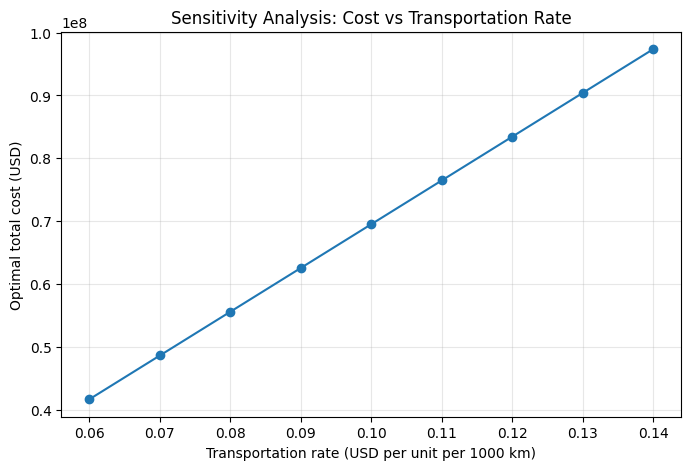

In [9]:
# Task9: Perform a Sensitivity Analysis: How does the total cost change if the transportation cost increases by 20%? Provide a graph of cost vs. transportation rate

import numpy as np
import matplotlib.pyplot as plt

prod = pd.read_excel("production.xlsx")
conn = pd.read_excel("connections.xlsx")
dem = pd.read_excel("demand.xlsx")
cons = pd.read_excel("constraints.xlsx")

supply = prod.set_index("Site Code")["Unit Production"].astype(float).to_dict()
prd_list = sorted(supply.keys(), key=str)

dem["Country_Code"] = dem["Country_Code"].astype(str).str.strip()
demand_mkt = dem.set_index("Country_Code")["Unit Demand"].astype(float).to_dict()
mkt_list = sorted(demand_mkt.keys(), key=str)

cons["Constraint Type"] = cons["Constraint Type"].astype(str).str.strip()
cons["Source"] = cons["Source"].astype(str).str.strip()
cons["Destination"] = cons["Destination"].astype(str).str.strip()
forbidden = set((t, s, d) for t, s, d in zip(cons["Constraint Type"], cons["Source"], cons["Destination"]))

def build_arcs_with_dist(conn_type, left, right):
    sub = conn[conn["Type"] == conn_type].copy()
    sub[[left, right]] = sub["Connection"].astype(str).str.split("-", expand=True)
    sub[left] = sub[left].str.strip()
    sub[right] = sub[right].str.strip()
    sub["Distance"] = sub["Distance"].astype(float)

    sub = sub.groupby([left, right], as_index=False)["Distance"].min()

    arcs = list(zip(sub[left], sub[right]))
    dist = {(r[left], r[right]): float(r["Distance"]) for _, r in sub.iterrows()}
    return arcs, dist

pg_arcs, dist_pg = build_arcs_with_dist("PMP-GDC", "PRD", "GDC")
gw_arcs, dist_gw = build_arcs_with_dist("GDC-WHS", "GDC", "WHS")
wm_arcs, dist_wm = build_arcs_with_dist("WHS-MKT", "WHS", "MKT")

pg_arcs = [(p, g) for (p, g) in pg_arcs if p in prd_list]
wm_arcs = [(w, m) for (w, m) in wm_arcs if m in mkt_list]

pg_arcs = [(p, g) for (p, g) in pg_arcs if ("PMP-GDC", p, g) not in forbidden]
gw_arcs = [(g, w) for (g, w) in gw_arcs if ("GDC-WHS", g, w) not in forbidden]
wm_arcs = [(w, m) for (w, m) in wm_arcs if ("WHS-MKT", w, m) not in forbidden]

gdc_list = sorted({g for (_, g) in pg_arcs}, key=str)
whs_list = sorted({w for (_, w) in gw_arcs} | {w for (w, _) in wm_arcs}, key=str)

def solve_total_cost(rate_per_1000km=0.1):
    cost_pg = {a: rate_per_1000km * (dist_pg[a] / 1000.0) for a in pg_arcs}
    cost_gw = {a: rate_per_1000km * (dist_gw[a] / 1000.0) for a in gw_arcs}
    cost_wm = {a: rate_per_1000km * (dist_wm[a] / 1000.0) for a in wm_arcs}

    model = pulp.LpProblem("Sensitivity_Task7", pulp.LpMinimize)

    x_pg = pulp.LpVariable.dicts("x_pg", pg_arcs, lowBound=0)
    x_gw = pulp.LpVariable.dicts("x_gw", gw_arcs, lowBound=0)
    x_wm = pulp.LpVariable.dicts("x_wm", wm_arcs, lowBound=0)

    model += (
        pulp.lpSum(x_pg[a] * cost_pg[a] for a in pg_arcs) +
        pulp.lpSum(x_gw[a] * cost_gw[a] for a in gw_arcs) +
        pulp.lpSum(x_wm[a] * cost_wm[a] for a in wm_arcs)
    )

    for p in prd_list:
        model += pulp.lpSum(x_pg[(pp, g)] for (pp, g) in pg_arcs if pp == p) == supply[p]

    for g in gdc_list:
        inflow = pulp.lpSum(x_pg[(p, gg)] for (p, gg) in pg_arcs if gg == g)
        outflow = pulp.lpSum(x_gw[(gg, w)] for (gg, w) in gw_arcs if gg == g)
        model += inflow == outflow

    for w in whs_list:
        inflow = pulp.lpSum(x_gw[(g, ww)] for (g, ww) in gw_arcs if ww == w)
        outflow = pulp.lpSum(x_wm[(ww, m)] for (ww, m) in wm_arcs if ww == w)
        model += inflow == outflow

    for m in mkt_list:
        model += pulp.lpSum(x_wm[(w, mm)] for (w, mm) in wm_arcs if mm == m) >= demand_mkt[m]

    model.solve(pulp.PULP_CBC_CMD(msg=False))
    if pulp.LpStatus[model.status] != "Optimal":
        return None

    return float(pulp.value(model.objective))

base_rate = 0.1
rates = base_rate * np.linspace(0.6, 1.4, 9)  
costs = [solve_total_cost(r) for r in rates]

res = pd.DataFrame({
    "Transportation rate (USD per unit per 1000 km)": rates,
    "Optimal total cost (USD)": costs
})

base_cost = solve_total_cost(base_rate)
cost_plus_20 = solve_total_cost(base_rate * 1.2)

print(f"Base rate = {base_rate:.4f} -> Optimal cost = ${base_cost:,.2f}")
print(f"Rate +20% = {base_rate*1.2:.4f} -> Optimal cost = ${cost_plus_20:,.2f}")
print(f"Change = ${cost_plus_20 - base_cost:,.2f}\n")

display(res)

plt.figure(figsize=(8, 5))
plt.plot(res["Transportation rate (USD per unit per 1000 km)"], res["Optimal total cost (USD)"], marker="o")
plt.xlabel("Transportation rate (USD per unit per 1000 km)")
plt.ylabel("Optimal total cost (USD)")
plt.title("Sensitivity Analysis: Cost vs Transportation Rate")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Task10: Determine the Carbon Footprint of the optimized supply chain if emissions are 0.05 kg CO2 per Unit per 1000 km. Compare it with the baseline scenario

EMISSION_FACTOR = 0.05 
COST_RATE = 0.1         

prod = pd.read_excel("production.xlsx")
conn = pd.read_excel("connections.xlsx")
dem = pd.read_excel("demand.xlsx")
cons = pd.read_excel("constraints.xlsx")

supply = prod.set_index("Site Code")["Unit Production"].astype(float).to_dict()
prd_list = sorted(supply.keys(), key=str)

dem["Country_Code"] = dem["Country_Code"].astype(str).str.strip()
demand_mkt = dem.set_index("Country_Code")["Unit Demand"].astype(float).to_dict()
mkt_list = sorted(demand_mkt.keys(), key=str)

cons["Constraint Type"] = cons["Constraint Type"].astype(str).str.strip()
cons["Source"] = cons["Source"].astype(str).str.strip()
cons["Destination"] = cons["Destination"].astype(str).str.strip()
forbidden = set((t, s, d) for t, s, d in zip(cons["Constraint Type"], cons["Source"], cons["Destination"]))

def build_arcs(conn_type, left, right):
    sub = conn[conn["Type"] == conn_type].copy()
    sub[[left, right]] = sub["Connection"].astype(str).str.split("-", expand=True)
    sub[left] = sub[left].str.strip()
    sub[right] = sub[right].str.strip()
    sub["Distance"] = sub["Distance"].astype(float)

    sub = sub.groupby([left, right], as_index=False)["Distance"].min()

    arcs = list(zip(sub[left], sub[right]))
    dist = {(r[left], r[right]): float(r["Distance"]) for _, r in sub.iterrows()}
    cost = {a: COST_RATE * (dist[a] / 1000.0) for a in arcs}
    return arcs, dist, cost

def solve_model(apply_constraints: bool):
    pg_arcs, dist_pg, cost_pg = build_arcs("PMP-GDC", "PRD", "GDC")
    gw_arcs, dist_gw, cost_gw = build_arcs("GDC-WHS", "GDC", "WHS")
    wm_arcs, dist_wm, cost_wm = build_arcs("WHS-MKT", "WHS", "MKT")

    pg_arcs = [(p, g) for (p, g) in pg_arcs if p in prd_list]
    wm_arcs = [(w, m) for (w, m) in wm_arcs if m in mkt_list]

    if apply_constraints:
        pg_arcs = [(p, g) for (p, g) in pg_arcs if ("PMP-GDC", p, g) not in forbidden]
        gw_arcs = [(g, w) for (g, w) in gw_arcs if ("GDC-WHS", g, w) not in forbidden]
        wm_arcs = [(w, m) for (w, m) in wm_arcs if ("WHS-MKT", w, m) not in forbidden]

    gdc_list = sorted({g for (_, g) in pg_arcs}, key=str)
    gw_arcs = [(g, w) for (g, w) in gw_arcs if g in gdc_list]
    whs_list = sorted({w for (_, w) in gw_arcs}, key=str)
    wm_arcs = [(w, m) for (w, m) in wm_arcs if w in whs_list]

    model = pulp.LpProblem("SupplyChain_MinCost", pulp.LpMinimize)

    x_pg = pulp.LpVariable.dicts("x_pg", pg_arcs, lowBound=0)
    x_gw = pulp.LpVariable.dicts("x_gw", gw_arcs, lowBound=0)
    x_wm = pulp.LpVariable.dicts("x_wm", wm_arcs, lowBound=0)

    model += (
        pulp.lpSum(x_pg[a] * cost_pg[a] for a in pg_arcs) +
        pulp.lpSum(x_gw[a] * cost_gw[a] for a in gw_arcs) +
        pulp.lpSum(x_wm[a] * cost_wm[a] for a in wm_arcs)
    )

    for p in prd_list:
        model += pulp.lpSum(x_pg[(pp, g)] for (pp, g) in pg_arcs if pp == p) == supply[p]

    for g in gdc_list:
        inflow  = pulp.lpSum(x_pg[(p, gg)] for (p, gg) in pg_arcs if gg == g)
        outflow = pulp.lpSum(x_gw[(gg, w)] for (gg, w) in gw_arcs if gg == g)
        model += inflow == outflow

    for w in whs_list:
        inflow  = pulp.lpSum(x_gw[(g, ww)] for (g, ww) in gw_arcs if ww == w)
        outflow = pulp.lpSum(x_wm[(ww, m)] for (ww, m) in wm_arcs if ww == w)
        model += inflow == outflow

    for m in mkt_list:
        model += pulp.lpSum(x_wm[(w, mm)] for (w, mm) in wm_arcs if mm == m) >= demand_mkt[m]

    model.solve(pulp.PULP_CBC_CMD(msg=False))
    if pulp.LpStatus[model.status] != "Optimal":
        raise RuntimeError("No optimal solution")

    def extract(var_dict):
        out = {}
        for a, v in var_dict.items():
            val = v.value()
            if val is not None and val > 1e-6:
                out[a] = float(val)
        return out

    flows_pg = extract(x_pg)
    flows_gw = extract(x_gw)
    flows_wm = extract(x_wm)

    total_cost = float(pulp.value(model.objective))
    return total_cost, (flows_pg, flows_gw, flows_wm), (dist_pg, dist_gw, dist_wm)

def emissions_for_solution(flows, dists):
    flows_pg, flows_gw, flows_wm = flows
    dist_pg, dist_gw, dist_wm = dists

    def leg_emissions(flow_dict, dist_dict):
        return sum(units * (dist_dict[a] / 1000.0) * EMISSION_FACTOR for a, units in flow_dict.items())

    e_pg = leg_emissions(flows_pg, dist_pg)
    e_gw = leg_emissions(flows_gw, dist_gw)
    e_wm = leg_emissions(flows_wm, dist_wm)
    e_total = e_pg + e_gw + e_wm
    return e_pg, e_gw, e_wm, e_total

base_cost, base_flows, base_dists = solve_model(apply_constraints=False)
base_e_pg, base_e_gw, base_e_wm, base_e_total = emissions_for_solution(base_flows, base_dists)

opt_cost, opt_flows, opt_dists = solve_model(apply_constraints=True)
opt_e_pg, opt_e_gw, opt_e_wm, opt_e_total = emissions_for_solution(opt_flows, opt_dists)

print("BASELINE (no shipment constraints)  [Task 6]")
print(f"  Total cost = ${base_cost:,.2f}")
print(f"  Emissions PRD->GDC = {base_e_pg:,.2f} kg CO2")
print(f"  Emissions GDC->WHS = {base_e_gw:,.2f} kg CO2")
print(f"  Emissions WHS->MKT = {base_e_wm:,.2f} kg CO2")
print(f"  TOTAL emissions    = {base_e_total:,.2f} kg CO2  ({base_e_total/1000:,.2f} t CO2)\n")

print("OPTIMIZED (with shipment constraints)  [Task 7]")
print(f"  Total cost = ${opt_cost:,.2f}")
print(f"  Emissions PRD->GDC = {opt_e_pg:,.2f} kg CO2")
print(f"  Emissions GDC->WHS = {opt_e_gw:,.2f} kg CO2")
print(f"  Emissions WHS->MKT = {opt_e_wm:,.2f} kg CO2")
print(f"  TOTAL emissions    = {opt_e_total:,.2f} kg CO2  ({opt_e_total/1000:,.2f} t CO2)\n")

delta = opt_e_total - base_e_total
pct = (delta / base_e_total * 100.0) if base_e_total > 0 else 0.0
print(f"Difference (Optimized - Baseline) = {delta:,.2f} kg CO2  ({pct:.2f}%)")

BASELINE (no shipment constraints)  [Task 6]
  Total cost = $69,479,231.47
  Emissions PRD->GDC = 11,716,362.44 kg CO2
  Emissions GDC->WHS = 12,719,586.19 kg CO2
  Emissions WHS->MKT = 10,303,667.10 kg CO2
  TOTAL emissions    = 34,739,615.73 kg CO2  (34,739.62 t CO2)

OPTIMIZED (with shipment constraints)  [Task 7]
  Total cost = $69,530,764.54
  Emissions PRD->GDC = 11,716,362.44 kg CO2
  Emissions GDC->WHS = 12,001,173.80 kg CO2
  Emissions WHS->MKT = 11,047,846.04 kg CO2
  TOTAL emissions    = 34,765,382.27 kg CO2  (34,765.38 t CO2)

Difference (Optimized - Baseline) = 25,766.54 kg CO2  (0.07%)
